<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/Training_multilingual_BERT_on_xquad-ro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What if my dataset isn't on the Hub?

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [1]:
!pip install datasets evaluate transformers[sentencepiece]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 972.6 kB/s eta 0:00:00


In [23]:
!pip install transformers

In [2]:
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-test.json.gz

--2026-07-02 17:03:08--  https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/crux82/squad-it/master/SQuAD_it-train.json.gz [following]
--2026-07-02 17:03:09--  https://raw.githubusercontent.com/crux82/squad-it/master/SQuAD_it-train.json.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7725286 (7.4M) [application/octet-stream]
Saving to: ‘SQuAD_it-train.json.gz’

SQuAD_it-train.json 100%[===================>]   7.37M  --.-KB/s    in 0.09s   

2026-07-02 17:03:09 (79.0 MB/s) - ‘SQuAD_it-train.json.gz’ saved [7725286/7725286]

--202

In [4]:
!wget -O xquad.ro.json https://raw.githubusercontent.com/google-deepmind/xquad/master/xquad.ro.json

--2026-07-02 17:18:22--  https://raw.githubusercontent.com/google-deepmind/xquad/master/xquad.ro.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 661158 (646K) [text/plain]
Saving to: ‘xquad.ro.json’

xquad.ro.json       100%[===================>] 645.66K  --.-KB/s    in 0.03s   

2026-07-02 17:18:22 (22.0 MB/s) - ‘xquad.ro.json’ saved [661158/661158]



In [41]:
from datasets import load_dataset

xquad_ro_dataset = load_dataset("json", data_files="xquad.ro.json", split='train')

In [50]:
xquad_ro_dataset

Dataset({
    features: ['data', 'version'],
    num_rows: 48
})

In [21]:
xquad_ro_dataset['train'][0]

{'data': {'paragraphs': [{'context': 'Apărarea Panthers a cedat doar 308 puncte, clasându-se pe locul șase din ligă, în timp ce au dominat NFL la interceptări, în număr de 24 și s-au putut lăuda cu patru selecții la Pro Bowl. Jucătorul principal al apărării la Pro Bowl, Kawann Short, a condus echipa la numărul de sack-uri cu 11, forțând și trei fumble-uri și recuperând două. Coechipierul de linie Mario Addison a adăugat încă 6½ sack-uri. Din linia Panthers a făcut parte și veteranul apărător din extremă Jared Allen, care a participat de 5 ori la Pro Bowl, fiind liderul activ al NFL la numărul de sack-uri de-a lungul carierei, în număr de 136, alături de apărătorul din extremă Kony Ealy, care a avut 5 sack-uri în doar 9 meciuri pe poziție de starter. În spatele lor, au fost selectați și doi dintre cei trei jucători din spatele liniei defensive ai Panthers pentru a juca la Pro Bowl: Thomas Davis și Luke Kuechly. Davis a adunat 5½ sack-uri, patru fumble-uri forțate, și patru interceptări,

In [6]:
from datasets import load_dataset

split_dataset = xquad_ro_dataset.train_test_split(test_size=0.2, seed=42)

In [31]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['data', 'version'],
        num_rows: 38
    })
    test: Dataset({
        features: ['data', 'version'],
        num_rows: 10
    })
})

In [42]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader

checkpoint = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(examples):
    questions = []
    contexts = []
    start_positions = []
    end_positions = []

    for data_item in examples['data']:
        for paragraph in data_item['paragraphs']:
            context = paragraph['context']
            for qa in paragraph['qas']:
                questions.append(qa['question'])
                contexts.append(context)

                if qa['answers'] and len(qa['answers']) > 0:
                    ans = qa['answers'][0]
                    start_char = ans['answer_start']
                    end_char = start_char + len(ans['text'])
                else:
                    start_char, end_char = 0, 0

                start_positions.append(start_char)
                end_positions.append(end_char)

    tokenized_inputs = tokenizer(
        questions,
        contexts,
        truncation=True,
        padding="max_length",
        max_length=384,
        return_offsets_mapping=True
    )

    final_start_positions = []
    final_end_positions = []

    for i in range(len(questions)):
        start_tok = tokenized_inputs.char_to_token(i, start_positions[i], sequence_index=1)
        end_tok = tokenized_inputs.char_to_token(i, end_positions[i] - 1, sequence_index=1)

        final_start_positions.append(start_tok if start_tok is not None else 0)
        final_end_positions.append(end_tok if end_tok is not None else 0)

    tokenized_inputs.pop("offset_mapping")

    tokenized_inputs["start_positions"] = final_start_positions
    tokenized_inputs["end_positions"] = final_end_positions

    return tokenized_inputs

tokenized_datasets = split_dataset.map(tokenize_function, batched=True, remove_columns=['data', 'version'])

tokenized_datasets.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "start_positions", "end_positions"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    batch_size=8,
    collate_fn=data_collator
)


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/38 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

In [30]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['data', 'version'],
        num_rows: 38
    })
    test: Dataset({
        features: ['data', 'version'],
        num_rows: 10
    })
})

In [31]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'],
        num_rows: 955
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'],
        num_rows: 235
    })
})

In [43]:
tokenized_datasets.set_format("torch")
tokenized_datasets['train'].column_names

['input_ids',
 'token_type_ids',
 'attention_mask',
 'start_positions',
 'end_positions']

In [33]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'],
        num_rows: 955
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'],
        num_rows: 235
    })
})

In [44]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets['train'], shuffle=True, batch_size=8, collate_fn=data_collator
)

test_dataloader = DataLoader(
    tokenized_datasets['test'], shuffle=False, batch_size=8, collate_fn=data_collator
)

In [45]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

for batch in train_dataloader:
  break
{k: v.shape for k, v in batch.items()}

{'input_ids': torch.Size([8, 384]),
 'token_type_ids': torch.Size([8, 384]),
 'attention_mask': torch.Size([8, 384]),
 'start_positions': torch.Size([8]),
 'end_positions': torch.Size([8])}

In [46]:
from transformers import AutoModelForQuestionAnswering

model = AutoModelForQuestionAnswering.from_pretrained(checkpoint, num_labels=2)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

In [47]:
import torch

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
model.to(device)

for batch in train_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}

    outputs = model(**batch)
    break
outputs

QuestionAnsweringModelOutput(loss=tensor(6.0171, device='cuda:0', grad_fn=<DivBackward0>), start_logits=tensor([[-0.3663, -0.0354, -0.3365,  ..., -0.2003, -0.0472, -0.2044],
        [-0.3082,  0.0120, -0.5618,  ..., -0.1797, -0.1694, -0.1954],
        [-0.3023, -0.0102, -0.2165,  ..., -0.1543, -0.2806, -0.1064],
        ...,
        [-0.3041,  0.0364, -0.3797,  ..., -0.3883, -0.3412, -0.4022],
        [-0.3379, -0.0285, -0.0742,  ..., -0.0297, -0.2665, -0.3542],
        [-0.3820, -0.0251, -0.2310,  ...,  0.0379,  0.2123,  0.1819]],
       device='cuda:0', grad_fn=<CloneBackward0>), end_logits=tensor([[ 0.3646,  0.1609, -0.2489,  ...,  0.1704,  0.3579,  0.0373],
        [ 0.2908,  0.2100,  0.0448,  ...,  0.2765,  0.1993,  0.0008],
        [ 0.3183,  0.2640, -0.2059,  ..., -0.0550,  0.0102, -0.0779],
        ...,
        [ 0.3042,  0.2212,  0.1677,  ...,  0.1332,  0.1087, -0.4222],
        [ 0.3158,  0.2521, -0.1183,  ...,  0.3963, -0.0128, -0.4247],
        [ 0.1693,  0.1579, -0.0161,  

In [48]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)


In [53]:
from transformers import get_scheduler

num_epochs=5
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)
num_training_steps

600

In [54]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))
loss_list = []
model.train()
for epoch in range(num_epochs):
  total_loss = 0
  for batch in train_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    optimizer.zero_grad()

    outputs = model(**batch)
    loss = outputs.loss

    loss.backward()
    optimizer.step()
    lr_scheduler.step()

    total_loss += loss.item()

    progress_bar.update(1)

    loss_list.append(loss.item())

  print(f"Mean loss: {total_loss / len(train_dataloader):.4f}")

  0%|          | 0/600 [00:00<?, ?it/s]

Mean loss: 0.6621
Mean loss: 0.4383
Mean loss: 0.1737
Mean loss: 0.0665
Mean loss: 0.0405


In [51]:
!pip install matplotlib

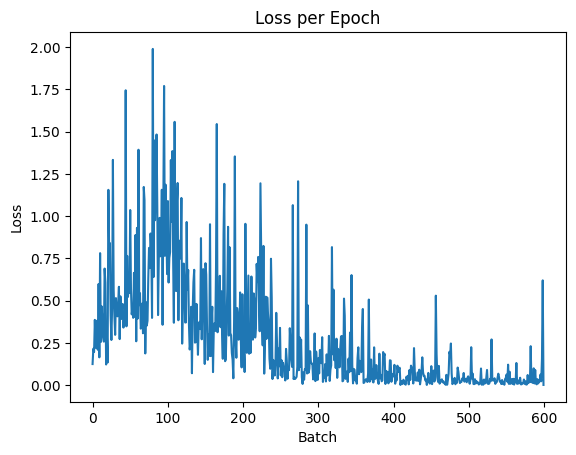

In [55]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.show()

In [57]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [59]:
import evaluate

metric = evaluate.load('squad')

all_preds = []
all_references = []
model.eval()
for batch in test_dataloader:
  batch = {k: v.to(device) for k,v in batch.items()}
  with torch.no_grad():
    outputs = model(**batch)

  start_preds = torch.argmax(outputs.start_logits, dim=-1).cpu().tolist()
  end_preds = torch.argmax(outputs.end_logits, dim=-1).cpu().tolist()

  for i in range(len(start_preds)):
    pred_text = tokenizer.decode(batch['input_ids'][i][start_preds[i]:end_preds[i]+1], skip_special_tokens=True)
    ref_text = tokenizer.decode(batch['input_ids'][i][batch['start_positions'][i]:batch['end_positions'][i]+1], skip_special_tokens=True)

    all_preds.append({
        'id': str(len(all_preds)),
        'prediction_text': pred_text.strip()
    })

    all_references.append({
        'id': str(len(all_references)),
        'answers': {
            "answer_start": [int(batch['start_positions'][i].cpu())],
            'text': [ref_text.strip()]
        }
    })

results = metric.compute(predictions=all_preds, references=all_references)
results

{'exact_match': 36.59574468085106, 'f1': 48.459397427511355}